# Tehtävä:
Valitkaa tutkimuksenne kohteeksi haluamanne tietoaineisto. Kyseessä voi olla jokin verkon datapankeista
löytyvä tietoaineisto tai muulla tavoin (esim. web-louhinnan tekniikoin) kerätty aineisto.
Esimerkkejä verkossa saatavilla olevista aineistoista ja aineistokokoelmista:
- __[University of California Irvinen koneoppimisen tietovarasto](http://archive.ics.uci.edu/ml/datasets)__.
- __[Kagglen aineistopankki](https://www.kaggle.com/datasets)__.
- __[Helsinki Region Infoshare](http://www.hri.fi/fi/)__.
- __[Väestörekisterikeskuksen avoindata.fi-palvelu:](https://www.avoindata.fi/)__.
Voitte käyttää myös mitä tahansa muuta teitä kiinnostavaa aineistoa.
Projektityössä noudatetaan CRISP-DM-mallia. Tutkimuskysymykset saatte keksiä itse.
Työ alkaa tavoitteenasettelusta. Valitkaa aluksi teitä kiinnostavat tutkimuskysymykset: mitä ennalta
tuntematonta haluatte saada aineistostanne selville **(CRISP-DM-mallin vaihe 1)**?
Kuvatkaa aineistonne **(vaihe 2)** ja esikäsitelkää se **(vaihe 3)** valitsemienne analyysimenetelmien
vaatimaan muotoon. Analysoikaa aineisto soveltuvin menetelmin **(vaihe 4)**, tulkitkaa tulokset
**(vaihe 5)** ja kuvatkaa, millä tavoin tuloksia voi hyödyntää **(vaihe 6)**.

# Tuotokset:
Viimeisellä viikolla pidetään seminaaritilaisuus, jossa kukin tiimi esittelee projektinsa saavutukset.
Esityksen lisäksi tuotoksena palautetaan:
· linkki havainnolliseen ja esityskelpoiseen Jupyter Notebookina toteutettuun analyysiraporttiin,
jossa kuvataan ja toteutetaan tiedonlouhintaprosessin eteneminen CRISP-DMmallin
mukaisesti.

# Arviointi:
Projektityön perusteella voi saada 25% kurssin kokonaispistemäärästä. Työstä saatavaan pistemäärään
vaikuttavat seuraavat seikat:
· kysymyksenasettelun haastavuus ja omaleimaisuus
· aineiston soveltuvuus asetettuihin tutkimuskysymyksiin
· aineiston käsittelyn (keruu, esikäsittely, analyysi) tekninen oikeellisuus ja innovatiivisuus
· tulosten kuvaaminen ja oikea tulkinta sekä tehtyjen johtopäätösten perustelu
· dokumenttien ymmärrettävyys ja kattavuus
· seminaariesityksen laatu

# Business Understanding
The first phase is to understand the business problem that needs to be solved.
- What is the goal of the analysis?
- What are the requirements and constraints?
- What is the expected outcome?


### - Kesken -

# Data Understanding
The second phase is to collect and explore the data.
- What data is available? What are the characteristics of the data (variable types, value distributions etc.)?
- Are there any quality issues with the data (missing values, outliers, nonsensical values)?

In [32]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../datasets/Imdb_Movie_Dataset.csv', delimiter=',')

print(df.describe())
print(df.columns)

                 id  vote_average    vote_count       revenue       runtime  \
count  1.048575e+06  1.048575e+06  1.048575e+06  1.048575e+06  1.048575e+06   
mean   7.546888e+05  2.041560e+00  2.045584e+01  7.604112e+05  4.822610e+01   
std    4.207457e+05  3.097234e+00  3.315669e+02  1.944925e+07  6.057823e+01   
min    2.000000e+00  0.000000e+00  0.000000e+00 -1.200000e+01 -2.800000e+01   
25%    3.846625e+05  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
50%    8.183790e+05  0.000000e+00  0.000000e+00  0.000000e+00  2.300000e+01   
75%    1.140640e+06  5.000000e+00  1.000000e+00  0.000000e+00  8.900000e+01   
max    1.411041e+06  1.000000e+01  3.449500e+04  5.000000e+09  1.440000e+04   

             budget    popularity  
count  1.048575e+06  1.048575e+06  
mean   2.913232e+05  1.276393e+00  
std    5.319290e+06  7.889555e+00  
min    0.000000e+00  0.000000e+00  
25%    0.000000e+00  6.000000e-01  
50%    0.000000e+00  6.000000e-01  
75%    0.000000e+00  9.170000e-01  


# Data Preparation
 The third phase is to preprocess the data.
 - This includes cleaning the data, transforming the data, and selecting the relevant features.
  - These steps should be documented in such detail that they can be reproduced later.

In [33]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore


# Load dataset
df = pd.read_csv('../datasets/Imdb_Movie_Dataset.csv', delimiter=',')

# Check for missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

# Drop irrelevant columns with excessive missing values
df.drop(columns=['tagline', 'keywords', 'spoken_languages', 'production_countries'], inplace=True, errors='ignore')

# Fill missing values in essential columns
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')  # Convert to datetime
df['release_date'] = df['release_date'].fillna(df['release_date'].mode()[0])  # Fill missing release dates with the most frequent value
df['genres'] = df['genres'].fillna('Unknown')
df['production_companies'] = df['production_companies'].fillna('Unknown')

# Drop remaining rows with missing values
df.dropna(inplace=True)

# Remove nonsensical values
df = df[(df['budget'] > 1000) & (df['revenue'] > 1000)]  # Remove unrealistic budget/revenue
df = df[(df['runtime'] >= 10) & (df['runtime'] <= 300)]  # Keep reasonable runtime

# Select relevant columns
df = df[['title', 'vote_average', 'vote_count', 'revenue', 'budget', 'runtime',
         'popularity', 'genres', 'production_companies']]

# Convert genres into binary columns (One-Hot Encoding)
genre_dummies = df['genres'].str.get_dummies(sep=', ')
df = df.join(genre_dummies)  # Add new binary genre columns

# Drop non-numeric columns **if they exist**
columns_to_drop = ['title', 'genres', 'production_companies']
df.drop(columns=[col for col in columns_to_drop if col in df.columns], inplace=True)

# Standardization
scaler = StandardScaler()
df[['budget', 'revenue', 'runtime', 'popularity', 'vote_count']] = scaler.fit_transform(
    df[['budget', 'revenue', 'runtime', 'popularity', 'vote_count']]
)

# Remove Outliers using Z-score
numerical_cols = ['vote_average', 'vote_count', 'revenue', 'budget', 'runtime', 'popularity']
df = df[(df[numerical_cols].apply(zscore).abs() < 3).all(axis=1)]  # Keep rows within 3 standard deviations

# Feature Engineering - Log Transformation
df['log_budget'] = np.log1p(df['budget'])
df['log_revenue'] = np.log1p(df['revenue'])
df['log_popularity'] = np.log1p(df['popularity'])

# Drop original columns after log transformation
df.drop(columns=['budget', 'revenue', 'popularity'], inplace=True)

# Prepare Data for Modeling
X_rating = df.drop(columns=['vote_average'])
y_rating = df['vote_average']

X_genre = df.drop(columns=['vote_average'])
y_genre = genre_dummies  # Use multi-label classification

# Ensure X_genre and y_genre have the same number of samples
X_genre, y_genre = X_genre.align(y_genre, join='inner', axis=0)

X_clustering = df[['log_budget', 'log_revenue', 'runtime', 'log_popularity']]

# Print dataset shape and first few rows after cleaning
print("\nFinal dataset shape:", df.shape)

# Display a small sample of the cleaned dataset
print("\nSample of cleaned dataset (limited columns for readability):")
print(df.head())  # Removed references to non-existing 'title' or 'genres'



Missing values before cleaning:
id                           0
title                       13
vote_average                 0
vote_count                   0
status                       0
release_date            181817
revenue                      0
runtime                      0
adult                        0
budget                       0
imdb_id                 488003
original_language            0
original_title              13
overview                215824
popularity                   0
tagline                 895847
genres                  414972
production_companies    568428
production_countries    463497
spoken_languages        440662
keywords                755954
dtype: int64

Final dataset shape: (8956, 26)

Sample of cleaned dataset (limited columns for readability):
     vote_average  vote_count   runtime  Action  Adventure  Animation  Comedy  \
245         8.242    2.999314  0.900528       0          0          0       1   
247         7.662    2.995643  1.444262       

# Modeling
The fourth phase is to choose a machine learning method and train the model.
- This phase also includes the validation of the model.
- Documentation needs include: which method was used, which parameters were used, what was the performance of the model?

Linear regression: Movie rating prediction
genre prediction: random forest

Recommending system?: clustering


## Part 1: Linear regression

## Part 2: Genre prediction
- The dataset is split into training and testing sets using train_test_split.
- X_genre contains the features, and y_genre contains the target labels.
- test_size=0.3 means 30% of the data is used for testing, and 70% for training.
- random_state=42 ensures reproducibility of the split.

- A Random Forest Classifier is trained on the training set.
- n_estimators=100 means 100 decision trees are used in the forest.

- The model is used to predict genres on the test set.
- The report includes precision, recall, and F1-score for each genre.

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from matplotlib import pyplot as plt
from sklearn.tree import plot_tree
import seaborn as sns
from sklearn.model_selection import GridSearchCV

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_genre, y_genre, test_size=0.3, random_state=42)

# Train Random Forest Classifier
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, None],
    "min_samples_split": [2, 5]
}

# Grid search for hyperparameter tuning
grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=2, scoring="f1_micro")
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

# Predict genres on test set
y_pred = best_model.predict(X_test)



print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=y_test.columns, zero_division=0))


Accuracy: 0.9434313360625233

Classification Report:
                  precision    recall  f1-score   support

         Action       1.00      1.00      1.00       636
      Adventure       1.00      1.00      1.00       393
      Animation       1.00      0.83      0.91       129
         Comedy       1.00      1.00      1.00      1013
          Crime       1.00      0.99      1.00       397
    Documentary       1.00      0.84      0.91        44
          Drama       1.00      1.00      1.00      1296
         Family       1.00      0.97      0.99       263
        Fantasy       1.00      0.94      0.97       215
        History       1.00      0.87      0.93       133
         Horror       1.00      0.98      0.99       321
          Music       1.00      0.82      0.90       107
        Mystery       1.00      0.94      0.97       239
        Romance       1.00      0.99      1.00       504
Science Fiction       1.00      0.97      0.98       237
       TV Movie       0.00      0

Most genres have a precision and recall of 1.00, meaning the model classifies them almost perfectly. However, some genres have a lower precision and recall, such as 'TV Movie' and 'Foreign'. This could be due to the low number of samples for these genres, making it harder for the model to learn their patterns.


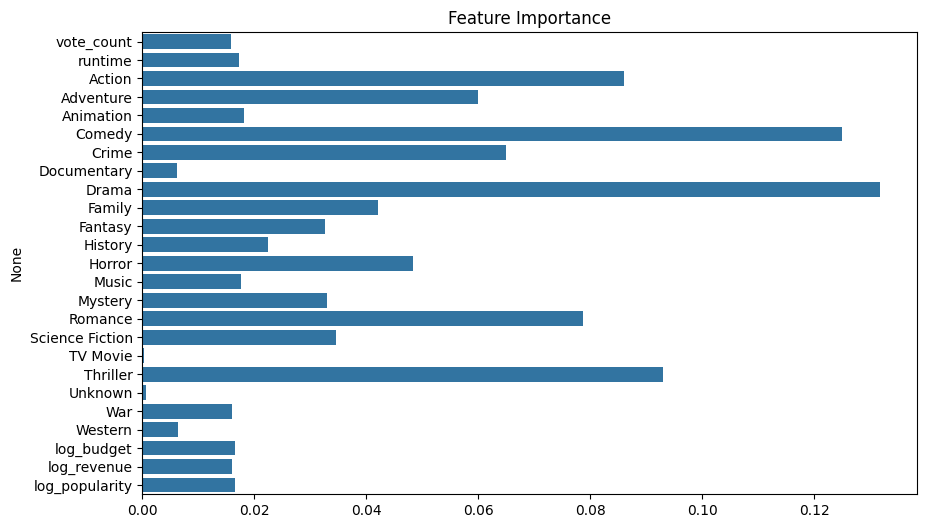

In [42]:
# Plot feature importance
importances = best_model.feature_importances_
features = X_train.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

From the plot, we can see that the most important features are drama and comedy. These features have the highest importance scores, indicating that they play a crucial role in predicting the genres of movies. This suggests that these genres have distinct patterns that the model can learn effectively.

## Part 3: Recommending System

# Evaluation
The fifth phase is to evaluate the model.
- How well does the model perform?
 - Does it meet the business requirements?

# Deployment
 The final phase is to deploy the model.
 - How will the model be used in practice?
   - How will the results be communicated?
      - This phase may involve creating a recommendation of how to use the model in practice, or what to do next